# 05 — Random Forest Detector (Structural Features Only)

Trains a Random Forest binary classifier using the same 14 kit-agnostic structural
features as the XGBoost model (notebook 04), enabling a direct apples-to-apples
comparison between the two algorithms on held-out data.

**Feature set (14):**
`has_{form,input,label,iframe,style}` · `input_count` · `label_count` · `form_count` ·
`button_count` · `signature_length` · `total_tag_count` · `form_density` ·
`input_per_form` · `has_credential_pattern`

- **Train:** `train_login_form-2026-08.csv` + `train_no_form-2026-08.csv` (deduplicated)
- **Retest:** `signed_retest_login_form.csv` + `signed_retest_no_form.csv` (held-out, unseen)

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_fscore_support, accuracy_score,
)

sys.path.insert(0, '../../src')
from features import CREDENTIAL_GROUP, STRUCTURAL_COLS, structural_features

RANDOM_STATE = 42

In [2]:
from pathlib import Path
_DB = Path("../../mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{_DB}")
if mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment("login-form-detection")
_active_run = mlflow.start_run(run_name="structural-random-forest")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow run   : {_active_run.info.run_id[:8]}")

Tracking URI : sqlite:////Users/nelson.mutua/Desktop/ThreatLabz/Login_Forms_Detection/mlflow.db
MLflow run   : 23803748


## 1. Load & Clean Data

In [3]:
lf = pd.read_csv("../../data/train/train_login_form-2026-08.csv", sep=";")
nf = pd.read_csv("../../data/train/train_no_form-2026-08.csv", index_col=0)

if "schreenshot_path" in nf.columns:
    nf.drop(columns=["schreenshot_path"], inplace=True)
lf.dropna(subset=["html_signature"], inplace=True)
nf.dropna(subset=["html_signature"], inplace=True)

df = pd.concat([lf, nf], ignore_index=True)
df = df.drop_duplicates(subset=["html_signature"]).reset_index(drop=True)
df["binary_label"] = (df["label"] == "LOGIN_FORM_MALICIOUS").astype(int)

print(f"Train dataset (deduplicated): {len(df)} rows | "
      f"Malicious: {df['binary_label'].sum()} | No-Form: {(df['binary_label']==0).sum()}")

Train dataset (deduplicated): 2072 rows | Malicious: 878 | No-Form: 1194


## 2. Structural Feature Extraction

In [4]:
df = structural_features(df)

print(f"Structural features : {len(STRUCTURAL_COLS)}")
print("\nMean by class:")
display(df.groupby("label")[STRUCTURAL_COLS].mean().round(3).T)

Structural features : 14

Mean by class:


label,LOGIN_FORM_MALICIOUS,NO_FORM
has_form,0.940,0.632
has_input,0.983,0.763
has_label,0.849,0.578
has_iframe,0.543,0.740
has_style,0.567,0.615
input_count,7.843,30.503
label_count,3.579,19.141
form_count,1.216,3.197
button_count,2.990,31.096
signature_length,1173.031,8649.126


## 3. Train / Test Split

In [5]:
X = df[STRUCTURAL_COLS].values
y = df["binary_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Feature matrix : {X.shape}  ({len(STRUCTURAL_COLS)} structural features)")
print(f"Train : {X_train.shape[0]} rows | Malicious: {y_train.sum()} | No-Form: {(y_train==0).sum()}")
print(f"Test  : {X_test.shape[0]} rows  | Malicious: {y_test.sum()} | No-Form: {(y_test==0).sum()}")

Feature matrix : (2072, 14)  (14 structural features)
Train : 1657 rows | Malicious: 702 | No-Form: 955
Test  : 415 rows  | Malicious: 176 | No-Form: 239


## 4. Train Random Forest

In [6]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 5. Evaluation


Train Set


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,97.4%,97.7%,97.5%,955
LOGIN_FORM_MALICIOUS,96.9%,96.4%,96.6%,702
Accuracy,,,97.2%,1657
ROC-AUC,,,99.8%,



Test Set


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,91.9%,94.6%,93.2%,239
LOGIN_FORM_MALICIOUS,92.3%,88.6%,90.4%,176
Accuracy,,,92.0%,415
ROC-AUC,,,96.5%,


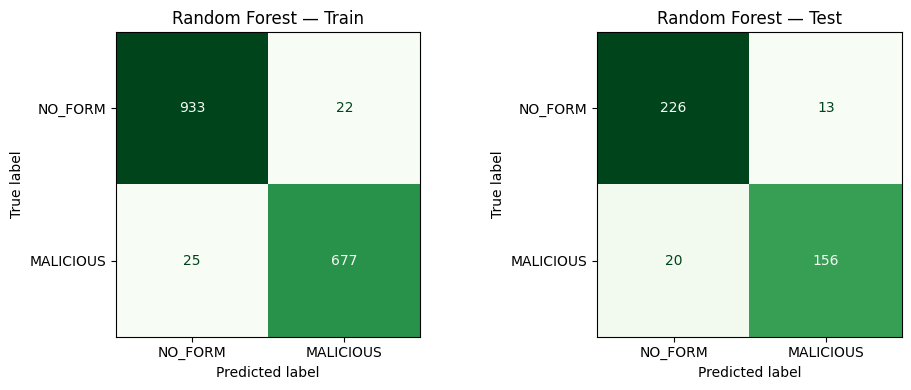

In [7]:
classes = ["NO_FORM", "LOGIN_FORM_MALICIOUS"]

def report_table(y_true, y_pred, y_prob, label):
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    rows = []
    for i, cls in enumerate(classes):
        rows.append({"Class": cls, "Precision": f"{prec[i]*100:.1f}%",
                     "Recall": f"{rec[i]*100:.1f}%", "F1-Score": f"{f1[i]*100:.1f}%",
                     "Support": int(sup[i])})
    rows.append({"Class": "Accuracy", "Precision": "", "Recall": "",
                 "F1-Score": f"{acc*100:.1f}%", "Support": int(sup.sum())})
    rows.append({"Class": "ROC-AUC",  "Precision": "", "Recall": "",
                 "F1-Score": f"{auc*100:.1f}%", "Support": ""})
    print(f"\n{label}")
    display(pd.DataFrame(rows).set_index("Class"))
    return acc, auc

y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_pred  = model.predict(X_test)
y_test_prob  = model.predict_proba(X_test)[:, 1]

train_acc, train_auc = report_table(y_train, y_train_pred, y_train_prob, "Train Set")
test_acc,  test_auc  = report_table(y_test,  y_test_pred,  y_test_prob,  "Test Set")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_t, y_p, title in [
    (axes[0], y_train, y_train_pred, "Train"),
    (axes[1], y_test,  y_test_pred,  "Test"),
]:
    cm = confusion_matrix(y_t, y_p)
    ConfusionMatrixDisplay(cm, display_labels=["NO_FORM", "MALICIOUS"]).plot(
        ax=ax, colorbar=False, cmap="Greens")
    ax.set_title(f"Random Forest — {title}")
plt.tight_layout()
plt.show()

## 6. Retest on Unseen Data

In [8]:
lf_rt = pd.read_csv("../../data/retest/signed_retest_login_form.csv", index_col=0)
nf_rt = pd.read_csv("../../data/retest/signed_retest_no_form.csv",    index_col=0)

for df_ in [lf_rt, nf_rt]:
    for junk in ("Unnamed: 0", "schreenshot_path"):
        if junk in df_.columns:
            df_.drop(columns=[junk], inplace=True)

df_rt = pd.concat([lf_rt, nf_rt], ignore_index=True)
df_rt.dropna(subset=["html_signature"], inplace=True)
df_rt.reset_index(drop=True, inplace=True)
df_rt["binary_label"] = df_rt["label"].str.contains("LOGIN_FORM", case=False, na=False).astype(int)
df_rt = structural_features(df_rt)

X_rt = df_rt[STRUCTURAL_COLS].values
y_rt = df_rt["binary_label"].values

print(f"Retest dataset : {len(df_rt)} rows | Malicious: {df_rt['binary_label'].sum()} | No-Form: {(df_rt['binary_label']==0).sum()}")

Retest dataset : 208 rows | Malicious: 109 | No-Form: 99



Retest Set (held-out)


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,90.7%,68.7%,78.2%,99
LOGIN_FORM_MALICIOUS,76.7%,93.6%,84.3%,109
Accuracy,,,81.7%,208
ROC-AUC,,,92.7%,


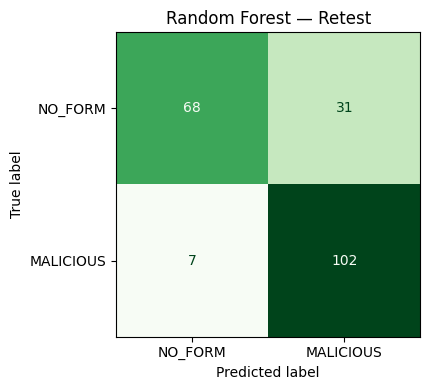


False Positives : 31  (NO_FORM flagged as Malicious)
False Negatives : 7  (Malicious Login Forms missed)


In [9]:
y_rt_pred = model.predict(X_rt)
y_rt_prob = model.predict_proba(X_rt)[:, 1]

retest_acc, retest_auc = report_table(y_rt, y_rt_pred, y_rt_prob, "Retest Set (held-out)")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_rt, y_rt_pred),
                       display_labels=["NO_FORM", "MALICIOUS"]).plot(
    ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Random Forest — Retest")
plt.tight_layout()
plt.show()

fp_rt = df_rt[(y_rt_pred == 1) & (y_rt == 0)]
fn_rt = df_rt[(y_rt_pred == 0) & (y_rt == 1)]
print(f"\nFalse Positives : {len(fp_rt)}  (NO_FORM flagged as Malicious)")
print(f"False Negatives : {len(fn_rt)}  (Malicious Login Forms missed)")

In [10]:
_prec_rt, _rec_rt, _f1_rt, _ = precision_recall_fscore_support(y_rt, y_rt_pred)
mlflow.log_metrics({
    "train_accuracy":       train_acc,
    "test_accuracy":        test_acc,
    "retest_accuracy":      retest_acc,
    "train_roc_auc":        train_auc,
    "test_roc_auc":         test_auc,
    "retest_roc_auc":       retest_auc,
    "retest_mal_precision": float(_prec_rt[1]),
    "retest_mal_recall":    float(_rec_rt[1]),
    "retest_mal_f1":        float(_f1_rt[1]),
})
print("Metrics logged to MLflow.")

Metrics logged to MLflow.


## 7. Save Model

In [11]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODELS_DIR / "structural_random_forest.pkl")

mlflow.log_params({
    "n_estimators":    model.n_estimators,
    "max_depth":       str(model.max_depth),
    "min_samples_leaf": model.min_samples_leaf,
    "max_features":    model.max_features,
    "class_weight":    str(model.class_weight),
    "feature_track":   "structural_14features",
    "random_state":    RANDOM_STATE,
})
mlflow.sklearn.log_model(model, "model")
mlflow.end_run()

print("Saved → models/structural_random_forest.pkl")
print("MLflow run complete.")

2026/09/07 10:48:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saved → models/structural_random_forest.pkl
MLflow run complete.
